# 4. Algorithm Comparison in Optimal Consumption Problem

DING Minjie, Spring 2025

____________________________________________________________________________________________________________________________________________

Differnet algorithm leads to different compuation speed. In this tutorial, I will firstly show computation difference with a simple example. Then, I will compare three methods to solve optimal consumption problem.

1. A simple example to show computation difference
2. Optimal Consumption Solution 1: Value Function Iteration using Loop
3. Optimal Consumption with Income Shock
4. Optimal Consumption Solution 2: Speed Up with Vectorization
5. Endogenous Grid Method
6. Optimal Consumption Solution 3: Speed Up with Endogenous Grid Method


______________________________________________________________________________________________________________________________________

# 1. A simple example to show computation difference

_____________________________________________________________________________________________________________________________________________

Some commonly used methods to speed up computation include:

1. Vectorization is faster than Loop.
2. Endogenous grid method is faster than value exogenous grid method. 
3. Use parpool to handle large dataset.

I use optimal consumption as an example to demonstrate speed difference.

In [1]:
cd"C:\Users\ading\A_TA_Notes"
pwd

ans = 'C:\Users\ading\A_TA_Notes'

In [2]:
clear all;  % Clears all variables from the workspace
close all;  % Closes all open figure windows
clc;        % Clears the Command Window

We want to sum up all dot product of elements in a matrix.

In [3]:
rng(100);                    % Set random seed
n = 1200;
A = random('Normal',0,1,n,n);  % Generate Matrix
A = A + A';                    % Make it symmetric

The first method is to use nested loops

In [4]:
% Code 1: Nested Loops for Total Calculation
tic; % Start the timer
total_1=0;
for i=1:n
    for j=1:n
        total_1=total_1+A(i,:)*A(j,:)';
    end
end
toc; % End the timer
total_1

历时 4.272858 秒。


total_1 = 3.0207e+06

We can also loop over another dimension.

In [5]:
% Code 2: Another Nested Loop Approach
tic; 
total_2=0;
for i=1:n
    for j=1:n
        total_2=total_2+A(:,i)'*A(:,j);
    end
end
toc;
total_2

历时 1.985000 秒。


total_2 = 3.0207e+06

However, loop one by one is slow. We can speed up with vectors. 

In [6]:
% Code 3: Vectorized Approach
tic; 
total_3=sum(sum(A*A'));
toc;
total_3

历时 0.049618 秒。


total_3 = 3.0207e+06

As we can see, vectorized approach takes much less time. 

## parpool

parpool enables us to handle several process simultaneously.

However, it needs initialization time. So, when dealing with small dataset, parpool may not be the fastest.

I have 6 par working together, but the time is longer than 1/6 of normal loops.

Use parpool when we encounter large dataset. 

In [7]:
%% Paralell Computing
parpool;

tic; % Start the timer
total_1=0;
parfor i=1:n
    for j=1:n
        total_1=total_1+A(i,:)*A(j,:)';
    end
end
toc; % End the timer

正在使用 'Processes' 配置文件启动并行池(parpool)...
已连接到具有 6 个工作进程的并行池。
历时 1.518947 秒。


___________________________________________________________________________________________________________________________________

# 2. Optimal Consumption Solution 1: Value Function Iteration using Loop

_________________________________________________________________________________________________________________________________________

Optimal consumption is a classical dynamic programming problem in economics. 

The problem can be formally described as follows:

- **Objective**: Maximize the expected utility over time:

  $$
  V(A) = \max_{c} \left\{ U(c) + \beta E[V(A') | A] \right\}
  $$

  where:
  -  V(A): Value function representing the maximum utility achievable with current assets $ A $.
  -  U(c): Utility derived from consumption $ c $. For simplicity, assume $U(c) = log(c)$.
  -  A': Future assets after consumption is made,


- **Asset Transition**: determined by the equation:

  $$
  A' = (1 + r)A + Y - c
  $$

  where:
  - r: is the interest rate
  - Y: is the income.

- **Constraints**:

  $$
  c \geq 0 \quad \text{and} \quad c \leq A + Y
  $$

In [8]:
%% Preparation

% Households
y = 1;              % Fixed income received by the agent
gamma   = 1;        % risk aversion in consumption utility function 
r = 0.03;           % The rate at which savings grow
beta = 0.95;        % How much future utility is worth today


% Assets grids
a_grid_size = 500;      % Number of asset grid
a_max = 20;        % Maximum value of asset
borrow_limit  = 0;   % Borrowing limit
a_grid_power   = 1;           % Power of grid interval, 1 for linear, 0 for L-shaped

a_grid = linspace(0,1,a_grid_size)';
a_grid = a_grid.^(1./a_grid_power);
a_grid = borrow_limit + (a_max - borrow_limit).*a_grid;


% Iteration setting
iter_max = 100;          % maxium iteration
iter_counter = 1;        % iteration counting   

iter_tolerance = 0.01;   % Tolerance for convergence 
iter_diff = 1;           % initial difference 

In [9]:
%% Local Function to Facilitate Expression

% Utility function
if gamma == 1
    u = @(c)log(c);
else    
    u = @(c)(c.^(1-gamma)-1)./(1-gamma);
end    

% Derivative of utility function to consumption
u1 = @(c) c.^(-gamma);

In [10]:
%% Initialize value functions and consumption function
V_guess        = u(r.*a_grid+y)./(1-beta);     % initial guess of value function
V_current      = zeros(a_grid_size,1);              % current value functions from iteration
V_next         = zeros(a_grid_size,1);              % new value functions from iteration
C              = zeros(a_grid_size,1);              % consumption policy
V_intermediate = zeros(a_grid_size, iter_max);      % intermediate value functions

In [11]:
%% Iteration using fmincon

options = optimoptions('fmincon','Display','off','TolX',1.0e-8);  % Options for the optimizer

tic
while iter_counter <= iter_max && iter_diff > iter_tolerance

    for i = 1:a_grid_size
        utility_function = @(c) - u(c) - beta * interp1(a_grid, V_current, (1+r)*(a_grid(i) + y - c));
        % we need to find maximum utility, and we have fmincon
        % so we try to find minimum negative utility
        % interpolated from the current value function.
        
        [C(i), V_next(i)] = fmincon(utility_function, y + 0.5 * a_grid(i),[],[],[],[],eps,a_grid(i) + y, [], options);
        % [x,fval] = fmincon(fun,x0,A,b,Aeq,beq,lb,ub,nonlcon,options)
        % find c(i) and V'(i) that maximize utility
        % x0 = income+0.5*assetGrid(i) 
        % upper bound =  assetGrid(i)+income
    end

    % Update value function
    V_next = -V_next;
    V_intermediate(:,iter_counter) = V_next;
    iter_diff = max(abs(V_current - V_next)); 
    V_current = V_next; 
    iter_counter = iter_counter + 1; 

end

% Displays the total number of iterations and the time taken
fprintf('Total iteration: %3i, Time: %2.6f \n', iter_counter, toc);

Total iteration:  31, Time: 48.294024 


Here are parameters which will affect total running time of iteration.

    a_grid_size: number of total grid
    a_grid_power: interval difference of grid
    gamma: type of utility function, when gamma doesn't equal to 1, the computation is more complicated. 

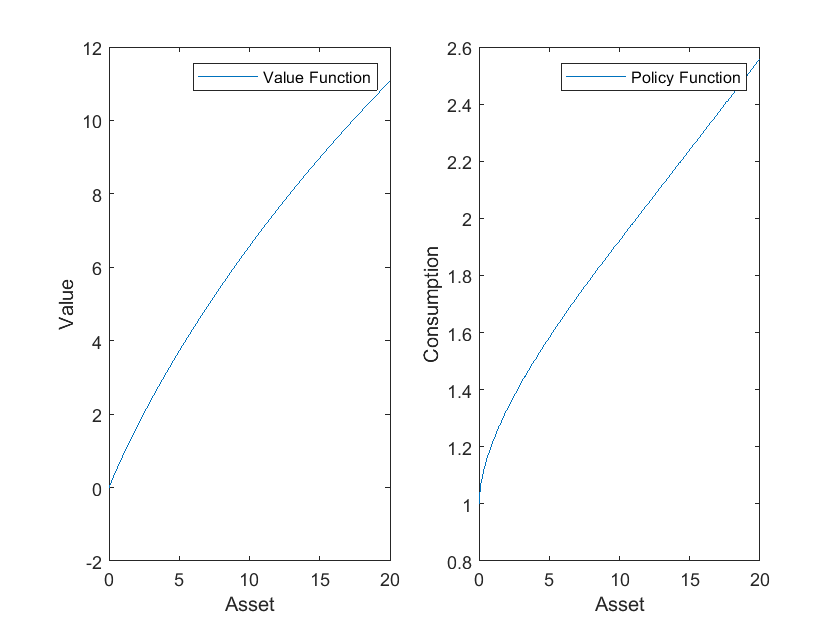

In [12]:
%% Plotting
figure(1)
subplot(1,2,1)
plot(a_grid,V_current)
legend('Value Function')
xlabel('Asset')
ylabel('Value')

subplot(1,2,2)
plot(a_grid,C)
legend('Policy Function')
xlabel('Asset')
ylabel('Consumption')

Sometimes, people use **"max"** to find value function.

Let's re-run clear code cell, and parameters code cell.

In [13]:
clear all;  % Clears all variables from the workspace
close all;  % Closes all open figure windows
clc;        % Clears the Command Window

In [14]:
%% Preparation

% Households
y = 1;              % Fixed income received by the agent
gamma   = 1;        % risk aversion in consumption utility function 
r = 0.03;           % The rate at which savings grow
beta = 0.95;        % How much future utility is worth today


% Assets grids
a_grid_size = 500;      % Number of asset grid
a_max = 20;        % Maximum value of asset
borrow_limit  = 0;   % Borrowing limit
a_grid_power   = 1;           % Power of grid interval, 1 for linear, 0 for L-shaped

a_grid = linspace(0,1,a_grid_size)';
a_grid = a_grid.^(1./a_grid_power);
a_grid = borrow_limit + (a_max - borrow_limit).*a_grid;


% Iteration setting
iter_max = 100;          % maxium iteration
iter_counter = 1;        % iteration counting   

iter_tolerance = 0.01;   % Tolerance for convergence 
iter_diff = 1;           % initial difference 

In [17]:
%% Initialize value functions and consumption function
V_guess        = u(r.*a_grid+y)./(1-beta);     % initial guess of value function
V_current      = zeros(a_grid_size,1);              % current value functions from iteration
V_next          = zeros(a_grid_size,1);              % new value functions from iteration
V_intermediate = zeros(a_grid_size, iter_max);      % intermediate value functions
C              = zeros(a_grid_size,1);              % consumption policy
S  = zeros(a_grid_size,1);                   % saving function
S_index = zeros(a_grid_size,1);              % saving choice index function

In [15]:
%% Local Function to Facilitate Expression

% Utility function
if gamma == 1
    u = @(c)log(c);
else    
    u = @(c)(c.^(1-gamma)-1)./(1-gamma);
end    

% Derivative of utility function to consumption
u1 = @(c) c.^(-gamma);

We use "max" here to find optimal choice.

In [18]:
%% Iteration using max

V_next = V_guess;

tic; 

while iter_counter <= iter_max && iter_diff > iter_tolerance
    
    iter_counter = iter_counter + 1;
    V_current = V_next;   % pass the old value to current value

    
    % loop over assets
    for i = 1:a_grid_size        
        cash = (1+r).*a_grid(i) + y;
        V_choice = u(max(cash-a_grid,1.0e-10)) + beta.*V_current;           
        [V_next(i),S_index(i)] = max(V_choice);
        S(i) = a_grid(S_index(i));      % Saving = i_th a_grid which maximize value function 
        C(i) = cash - S(i);            % Consumption = cash - saving
    end
    
    
    iter_diff = max(max(abs(V_next - V_current)));
   
    % disp(['Iteration no. ' int2str(iter_counter), ' max val fn diff is ' num2str(iter_diff)]);
end    

% Displays the total number of iterations and the time taken
fprintf('Total iteration: %3i, Time: %2.6f \n', iter_counter, toc);

Total iteration:  32, Time: 0.266263 


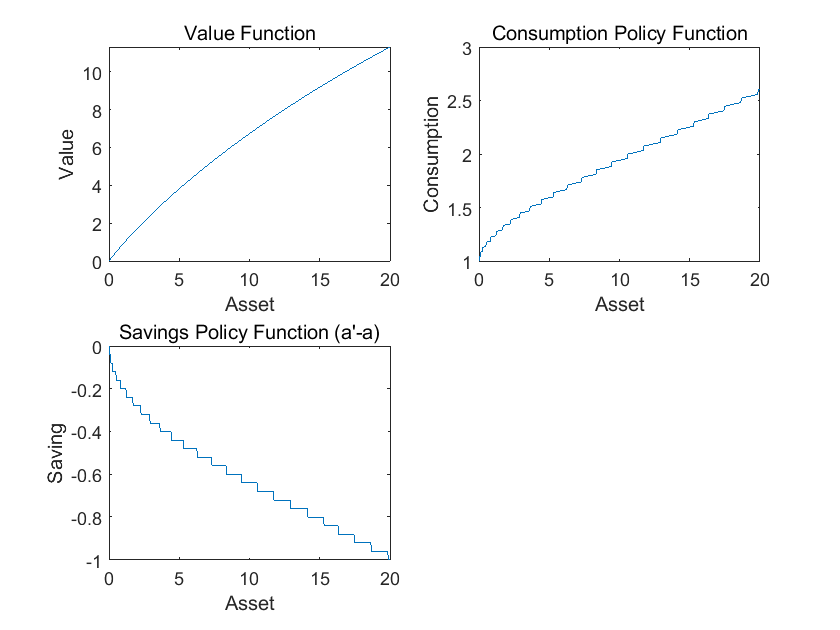

In [19]:
%% Plotting
figure(1)
subplot(2,2,1)
plot(a_grid,V_current)
title('Value Function')
xlabel('Asset')
ylabel('Value')

subplot(2,2,2)
plot(a_grid,C)
title('Consumption Policy Function')
xlabel('Asset')
ylabel('Consumption')

subplot(2,2,3)
plot(a_grid,S-a_grid)
title('Savings Policy Function (a''-a)')
xlabel('Asset')
ylabel('Saving')

This method is much more faster. But there is no interpolation, only find certain index. So, there is zig-zag thing in policy function.

________________________________________________________________________________________________________________________________________

# 3. Optimal Consumption with Income Shock

__________________________________________________________________________________________________________________________________________

Now we introduce new changes to the problem.

- The agent faces three possible income levels:
  $$  Y = [0.5, 1.0, 1.5] $$
  
- Each income level has an equal probability:
  $$ Pi_Y = [\frac{1}{3}, \frac{1}{3}, \frac{1}{3}] $$

- For each combination of asset levels and income states, we need to uses the `fmincon` optimization function to determine the optimal consumption level  C that maximizes the expected utility:
  
  $$
  \max_{c} \left\{ -\log(c) - \beta \sum_{j=1}^{3} \Pi_Y(j) V_0(A', Y(j)) \right\}
  $$

- The future assets A' after consumption are calculated based on the current assets, income, and chosen consumption.

In parameter section, here are newly added code lines:

- Y = [0.5;1.0;1.5];       % Income levels

- Pi_Y = [1/3; 1/3; 1/3];  % Income probabilitie
- N_Y = length(Y);         % Number of income levels

Others are the same, except for more abbreviation. 

In [20]:
%% Preparation

% Households
Y = [0.5;1.0;1.5];       % Income levels
Pi_Y = [1/3; 1/3; 1/3];  % Income probabilities  
r = 0.02;                % The rate at which savings grow
beta = 0.96;             % How much future utility is worth today

% Asset grid
A = (0:0.05:10)';        % Grid of asset from 0 to 10, increments of 0.05
N_A = length(A);         % Number of points in the asset grid
N_Y = length(Y);         % Number of income levels

% Maximum iterations
Max_iter = 100;          % maxium iteration
iter = 1;                % iteration start from 1

% Tolerance for convergence
tol = 0.01;              % tolerance, larger to shorten time
max_diff = 1;            % difference start

% Options for fmincon optimization
opts = optimoptions('fmincon','Display','off','TolX',1.0e-6);

% Initialize value function and consumption
V_0 = zeros(N_A, N_Y);   % current value functions
V_1 = zeros(N_A, N_Y);   % next value functions 
C = zeros(N_A, N_Y);     % consumption policy
V_save = zeros(N_A, N_Y, Max_iter);  % intermediate value functions

In iteration section, the changes are:

- Introduce another loop because of 3 income level.
- Future value in Bellman function now is expected value weighted by income probability.

In [21]:
%% Iteration
tic
while max_diff > tol
    for j = 1:N_Y
        for i = 1:N_A
            % Optimize consumption and update value function
            utility_function = @(x) -log(x) ...
                - beta * (Pi_Y(1)*interp1(A, V_0(:,1), (1+r)*(A(i) + Y(j) - x)) ...
                + Pi_Y(2)*interp1(A, V_0(:,2), (1+r)*(A(i) + Y(j) - x)) ...
                + Pi_Y(3)*interp1(A, V_0(:,3), (1+r)*(A(i) + Y(j) - x)));

            [C(i,j), V_1(i,j)] = fmincon(utility_function, ...
                0.5*Y(j)+0.5*A(i),[],[],[],[],eps,A(i)+Y(j),[],opts); 
        end
    end

    % Update the value function and check for convergence
    V_1 = -V_1; 
    V_save(:,:,iter) = V_1; 
    max_diff = max(max(abs(V_0 - V_1)));

    if mod(iter, 10) == 1
        fprintf('Iteration: %d, Max difference: %.8f\n', iter, max_diff);
    end

    V_0 = V_1; 
    iter = iter + 1;
end
fprintf('Total iteration: %3i, Time: %2.6f \n', iter, toc);

Iteration: 1, Max difference: 2.44234702
Iteration: 11, Max difference: 0.10095394
Iteration: 21, Max difference: 0.01114086
Total iteration:  25, Time: 46.076386 


The plotting section is the same. 

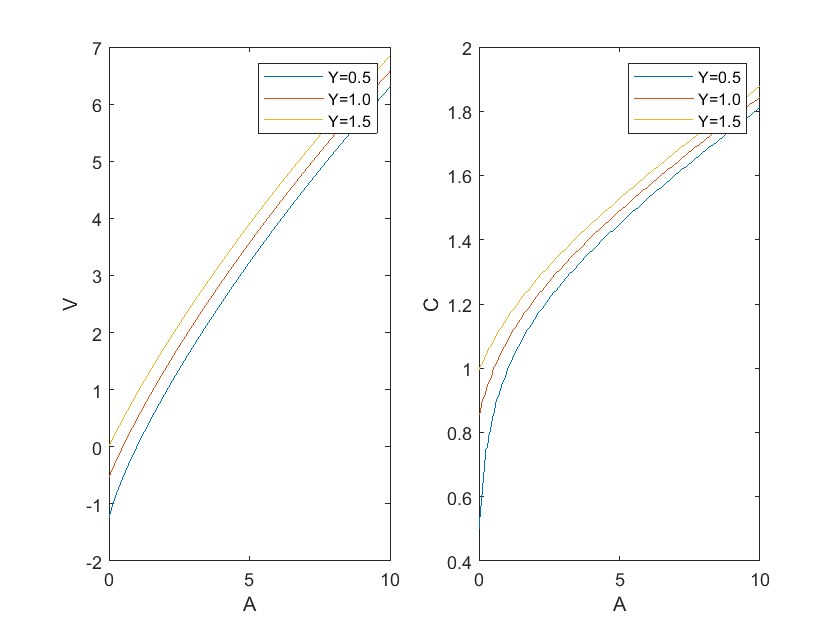

In [22]:
%% Plotting the value function for each income level
figure(1)
subplot(1,2,1)
plot(A, V_1(:,1), A, V_1(:,2), A, V_1(:,3))
legend('Y=0.5','Y=1.0','Y=1.5')
xlabel('A')
ylabel('V')

% Plotting the optimal consumption level for each income level
subplot(1,2,2)
plot(A, C(:,1), A, C(:,2), A, C(:,3))
legend('Y=0.5','Y=1.0','Y=1.5')
xlabel('A')
ylabel('C')

Now, there are many asset grid and several income levels, so we have a nested loop inside a loop. 

The computation takes much longer time than the case with constant income. 

_____________________________________________________________________________________________________________________________________

# 4. Optimal Consumption Solution 2: Speed Up with Vectorization

____________________________________________________________________________________________________________________________________________

Now we solve the model with value function iteration which is vertorized.

In preparation section, the key difference is how to initialize grids.

In [22]:
%% Preparation

% Households
ygrid = [0.5; 1.0; 1.5]; % Income levels
pi_y = repmat([1/3, 1/3, 1/3], 3, 1); % Income probabilities  
r = 0.02;                % The rate at which savings grow
beta = 0.96;             % How much future utility is worth today

% Asset grid
agrid = (0:0.05:10)';    % Grid of asset from 0 to 10, increments of 0.05
NA_grid = length(agrid); % Number of points in the asset grid 
NY_grid = length(ygrid);  % Number of income levels

% Maximum iterations
maxiter = 10^(3);        % maxium iteration
iter = 1;                % iteration start from 1

% Tolerance for convergence
tol_in = 1e-4;           % tolerance
max_diff = tol_in + 1;   % difference start

% Initialize grids
V_0 = zeros(NA_grid, NY_grid);  % current value functions
[AIND,YIND] = ndgrid(1:NA_grid,1:NY_grid);
Amat = agrid(AIND); 
Ymat = ygrid(YIND);
% ndgrid creates matrices AIND and YIND for indexing purposes, 
% helping to construct matrices of asset and income levels.

% Remember that in previous version, we use following code
% to initialize value function and consumption
% V_0 = zeros(N_A, N_Y);   % current value functions
% V_1 = zeros(N_A, N_Y);   % next value functions 
% C = zeros(N_A, N_Y);     % consumption policy

In iteration, we use Golden section method and a function written by Professor Jinhui Bai.

Note that in previous version, we use two loops to check each income level (N_Y) and each asset grids (N_A), one by one.

Here we use vectors, Amat(:)+Ymat(:), to avoid loops. In a single N_Y*N_A matrix, all income level and all asset grids are checked. 

Which means, we can check N_Y*N_A element everytime. 

So, the computation is much faster.

In [23]:
%% Iteration
disp('vfi loop, running...');
tic
while (max_diff > tol_in && iter < maxiter)

    % Objective function for goldenx
    objFun = @(x) log(x) + beta * sum(pi_y(YIND(:), :) .* ...
        interp1(agrid, V_0, (1+r)*(Amat(:)+Ymat(:)-x),'spline'), 2);

    % Optimization
    [C, V_1] = GoldenVec(objFun, eps * ones(NA_grid * NY_grid, 1), ...
        Amat(:) + Ymat(:), 1000, 1e-8);

    V_1 = reshape(V_1, NA_grid, NY_grid);
    max_diff = max(abs(V_0(:) - V_1(:)));
    V_0 = V_1;

    % Display progress every 50 iterations
    if mod(iter, 50) == 1
        fprintf('Iteration: %d, Max difference: %.8f\n', iter, max_diff);
    end

    iter = iter + 1;
end
fprintf('vertorized vfi total iteration: %3i, time: %2.6f \n',iter,toc);


%% GoldenVec function by Professor Jinhui Bai
function [x1, f1, exitflag] = GoldenVec(f, a, b, maxiter, tol, varargin)
% GOLDENX computes the local maximum of a univariate function on an interval using Golden Search.
% This function is a vectorized version of the Golden Search method.
%
% Inputs:
%   f       : name of the function to be maximized. The function should be in the form fval=f(x).
%   a, b    : left and right endpoints of the interval.
%   maxiter : maximum number of iterations.
%   tol     : convergence tolerance.
%   varargin: optional additional arguments for the function f.
%
% Outputs:
%   x1      : local maximum of the function f.
%   f1      : function value at the local maximum.
%   exitflag: condition of exit (1 = converged, 0 = maximum iteration reached).

% Copyright (c) 1997-2002, Paul L. Fackler & Mario J. Miranda
% paul_fackler@ncsu.edu, miranda.4@osu.edu

% Revised by Jinhui Bai, January 15, 2005

% Check if bracketing points have correct sizes and values
if ~isequal(size(a), size(b))
    error('Bracketing vectors must be of the same length.');
end

if any((b - a) <= 0)
    error('Lower and upper interval points are not in the correct sequence.');
end

% Define the Golden Section coefficients
alpha1 = (3 - sqrt(5)) / 2;
alpha2 = 1 - alpha1;

% Initialize section points and function evaluations
d = b - a;                 % Length of the interval
x1 = a + alpha1 * d;       % Left section point
x2 = a + alpha2 * d;       % Right section point
s = ones(size(x1));
f1 = feval(f, x1, varargin{:});
f2 = feval(f, x2, varargin{:});

% Iteration until convergence or maximum iteration is reached
iter = 0;
while any(d > tol) && (iter <= maxiter)
    d = d * alpha2;
    i = f2 > f1;

    x1(i) = x2(i);
    f1(i) = f2(i);

    d12 = (alpha2 - alpha1) * d;       % Distance between two section points
    x2 = x1 + s .* (i - (~i)) .* d12;
    s = sign(x2 - x1);
    f2 = feval(f, x2, varargin{:});

    iter = iter + 1;
end

% Return the larger of the two
i = f2 > f1;
x1(i) = x2(i);
f1(i) = f2(i);

% Define the exit flag
if all(d <= tol)
    exitflag = 1;
else
    exitflag = 0;
end
end

vfi loop, running...
Iteration: 1, Max difference: 2.44234704
Iteration: 51, Max difference: 0.00319405
Iteration: 101, Max difference: 0.00041483
vertorized vfi total iteration: 137, time: 0.366026 


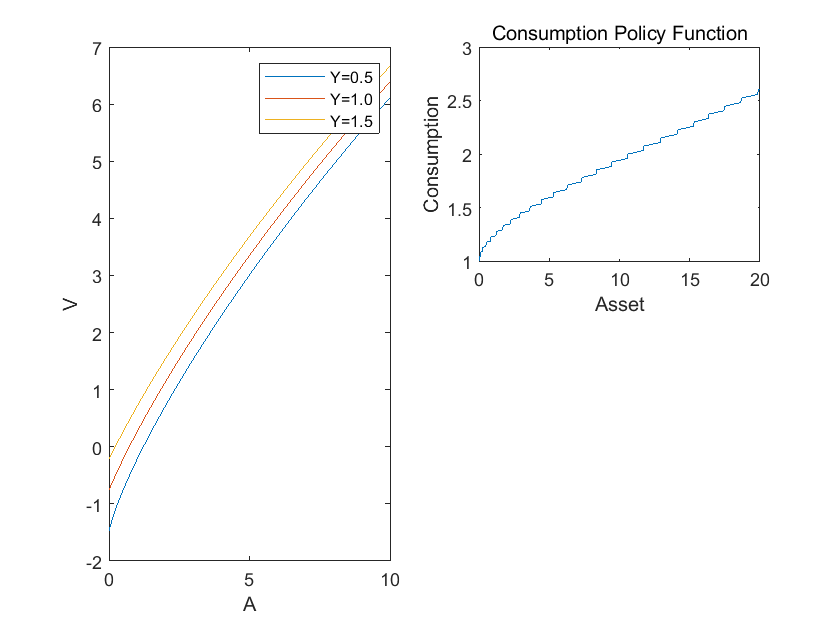

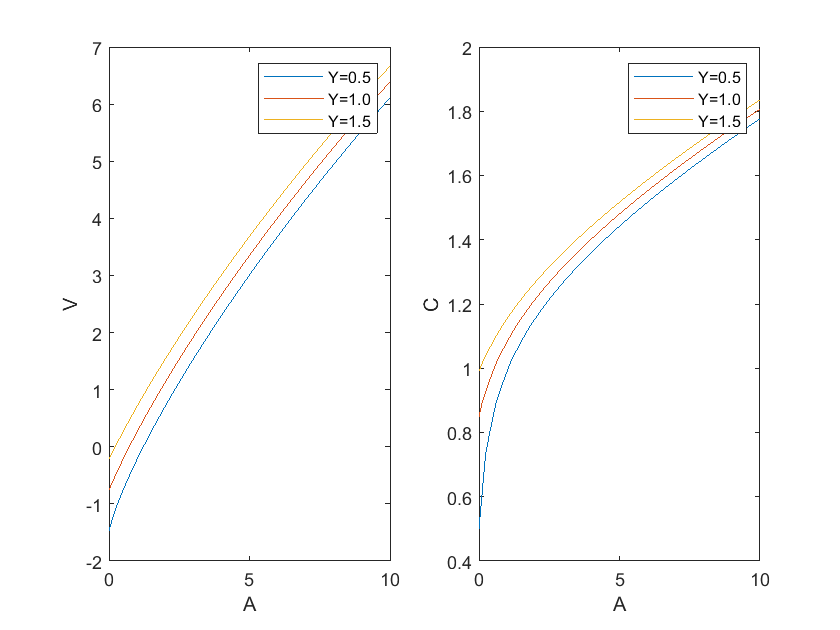

In [24]:
%% Plotting
C = reshape(C, NA_grid, NY_grid);

figure(1);
subplot(1,2,1);
plot(agrid, V_1(:,1), agrid, V_1(:,2), agrid, V_1(:,3));
xlabel('A');
ylabel('V');
legend(arrayfun(@(y) sprintf('Y=%.1f', y), ygrid,'UniformOutput',false));

subplot(1,2,2);
plot(agrid, C);
xlabel('A');
ylabel('C');
legend(arrayfun(@(y) sprintf('Y=%.1f', y), ygrid,'UniformOutput',false));

__________________________________________________________________________________________________________________________________________

# 5. Endogenous Grid Method

_________________________________________________________________________________________________________________________________________

We need to find the consumption policy function (blue arrow) and asset policy function (red arrow).  

That is, given $A_t$, we need to know $C_t$ and $A_{t+1}$. 

<div style="text-align: center;">
    <img src="./Figures/EGM_1.jpg" width="500"/>
</div>

We have a guess value for $C_t$. Or a guess value for $A_t$, they are connected by budget constraint.

With Euler equation, we solve for an endogenou $C_{endo}$. And with budget constraint, we ge $C_{endo}$.

The calculation is in the black arrows. 

<div style = 'text-align: center'>
    <img src = './Figures/EGM_2.jpg' width = '700'>
</div>

Now we have relation between $A_{endo}$ and $A_{guess}$. 

We can get a new guess value $A_{guessnew}$ with this relation using interpolation, and a new guess value $A_{guessnew}$ by budget constraint.

Then iterate, until two guess values are close enough.  


<div style = 'text-align: center'>
    <img src = './Figures/EGM_3.jpg' width = '500'>
</div>

Sometimes, people interpolate the consumption function. 

Using the relation betwee $C_{endo}$ an $A_{endo}$, we can get a new guess valu $C_{guessnew}$ starting fro $A_{guess}$, and then ge $A_{guessnew}$ by budget constraint.
 
Then iterate, until new guess values are close enough. 

<div style = 'text-align: center'>
    <img src = './Figures/EGM_4.jpg' width = '500'>
</div>

You may ask why we use backward induction, why not forward induction like in the graph. 

The main reason is that,$C_{endo}$ can be written explicitly in backward induction, which is computationally fast.
 
If we use forward induction, we still need to solve a nonlinear function. 

<div style="text-align: center;">
    <img src="./Figures/EGM_5.jpg" width="500">
</div>


_______________________________________________________________________________________________________________________________________

# 6. Optimal Consumption Solution 3: Speed Up with Endogenous Grid Method

____________________________________________________________________________________________________________________________________________

In preparation section, it's the same.

In [25]:
%% Preparation

% Households
ygrid = [0.5; 1.0; 1.5]; % Income levels
pi_y = repmat([1/3, 1/3, 1/3], 3, 1); % Income probabilities  
r = 0.02;                % The rate at which savings grow
beta = 0.96;             % How much future utility is worth today

% Asset grid
agrid = (0:0.05:10)';    % Grid of asset from 0 to 10, increments of 0.05
NA_grid = length(agrid); % Number of points in the asset grid 
NY_grid = length(ygrid);  % Number of income levels

% Maximum iterations
maxiter = 10^(3);        % maxium iteration
iter = 1;                % iteration start from 1

% Tolerance for convergence
tol_in = 1e-4;           % tolerance
max_diff = tol_in + 1;   % difference start

% Initialize grids
V_0 = zeros(NA_grid, NY_grid);   % current value functions
[AIND,YIND] = ndgrid(1:NA_grid,1:NY_grid);
Amat = agrid(AIND); 
Ymat = ygrid(YIND);
% ndgrid creates matrices AIND and YIND for indexing purposes, 
% helping to construct matrices of asset and income levels.


Here in iteration, we don't have to deal with optimization problem, just pure iteration. 

We have: 

    interp1(a0(:,i),c0(:,i),Amat(:,i),'spline')

a0 and c0 is endogenous changed, this is why it's called endogenous grid method.

Remember that in Value function iteration, the code is:

    interp1(agrid, V_0, (1+r)*(Amat(:)+Ymat(:)-x)

The grids are exogenous there. 



Also, in EGM (endogenous grid method), interpolation is used to get optimal policy function,

while, in VFI (value function iteration), interpolation is used to fit data to existing exogenous grid, optimal value function is achieved by fmincon or other opizationmal function. 

In [26]:
%% Iteration

% Initial guess on future consumption.
cp0 = r*Amat+Ymat;  % cp is consumption projected
cpnext = cp0;

disp('endogenous grid loop, running...');
tic
while (max_diff > tol_in && iter < maxiter)
    % Derive current consumption and current assets    
    % Given guessed future consumption, we can get current consumption
    % and current asset, thus their mapping relation,
    % or consumption policy function.
    c0 = (beta*(1+r)*(cp0.^(-1))*pi_y').^(-1); % from Euler equation
    a0 = Amat/(1+r)+c0-Ymat;         % from budget constraint
    V = log(c0);

    % Update the guess for the consumption decision
    % Interpolation conditional on productivity realization
    % use default option for outbounders (no extrapolation)
    for i = 1:3
        cpnext(:,i)  = interp1(a0(:,i),c0(:,i),Amat(:,i),'spline');
    end

    % Consumption decision rule for a binding borrowing constraint
    idcon = (Amat+Ymat-cpnext)<0;
    cpnext(idcon) = Amat(idcon)+Ymat(idcon);

    % Compute and display distance
    max_diff = max(abs(cpnext(:)-cp0(:)));
    if mod(iter,50) == 1
        fprintf('Iteration: %d, Max difference: %.8f\n', iter, max_diff);
    end

    % Update iteration parameters
    iter = iter+1;
    cp0 = cpnext;
    c0 = cpnext;
end
fprintf('endogenous grid total iteration: %3i, time: %2.6f \n',iter,toc);

endogenous grid loop, running...
Iteration: 1, Max difference: 0.64808303
Iteration: 51, Max difference: 0.00021198
endogenous grid total iteration:  56, time: 0.019076 


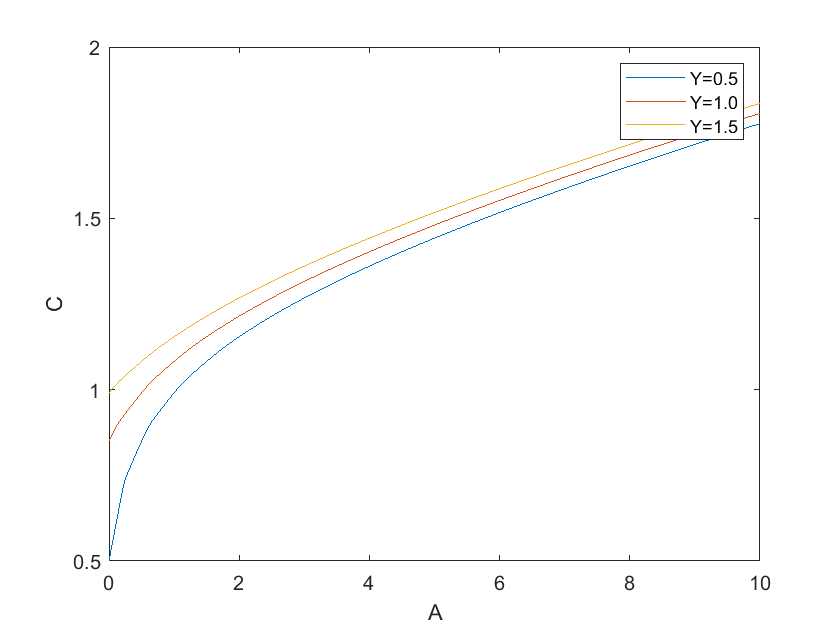

In [27]:
%% Plot results
figure(2);

plot(agrid, cp0);
xlabel('A');
ylabel('C');
legend(arrayfun(@(y) sprintf('Y=%.1f', y), ygrid,'UniformOutput',false));

___________________________________________________________________________________________________________________________________________

# Reference

______________________________________________________________________________________________________________________________________________________

1. Benjamin Moll,
   "Solving the Income Fluctuation Problem: Numerical Dynamic Programming",
   https://benjaminmoll.com/wp-content/uploads/2021/04/Lecture2_EC442_Moll.pdf

2. Benjamin Moll, "Heterogeneous-Agent Models and Methods", https://benjaminmoll.com/wp-content/uploads/2021/04/STEG_course.pdf